In [129]:
import pandas as pd

path = '../data/processed/ai4i2020_new.csv'
df = pd.read_csv(path, index_col='UDI')
print('Dataset loaded')
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

df.sample(10)

Dataset loaded
Rows: 9973
Columns: 13


,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rad/s],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
UDI,,,,,,,,,,,,,
693,L47872,0,297.7,309.1,154.880518,42.1,58,0,0,0,0,0,0
9175,L56354,0,297.8,308.9,195.930662,25.6,200,1,1,0,0,0,0
755,M15614,1,296.9,308.1,155.299397,44.3,219,0,0,0,0,0,0
5131,L52310,0,304.2,313.3,174.672552,35.7,180,0,0,0,0,0,0
5103,M19962,1,304.1,313.5,166.190251,33.6,108,0,0,0,0,0,0
9544,M24403,1,299.5,310.9,144.303823,48.7,119,0,0,0,0,0,0
7566,M22425,1,300.3,311.2,186.715323,25.6,139,0,0,0,0,0,0
2469,M17328,1,298.9,308.6,159.592907,40.4,131,0,0,0,0,0,0
4669,H34082,2,303.3,311.4,177.185826,27.9,55,0,0,0,0,0,0


In [130]:
print('Separating all column by type:\n')
identifier = [
    'UDI', 'Product ID', 'Type'
]
failure = [
    'TWF', 'HDF', 'PWF', 'OSF', 'RNF'
]
target = [
    'Machine failure'
]
feature = [
    'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rad/s]',	'Torque [Nm]', 'Tool wear [min]'
]

print(f'Identifier: {identifier}')
print(f'Failure: {failure}')
print(f'Features: {feature}')
print(f'Target: {target}')



Separating all column by type:

Identifier: ['UDI', 'Product ID', 'Type']
Failure: ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
Features: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rad/s]', 'Torque [Nm]', 'Tool wear [min]']
Target: ['Machine failure']


In [131]:
from sklearn.model_selection import train_test_split

X, y = df[feature], df[target[0]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size= 0.2, #80% train - 20% test
    random_state= 42,
    stratify= y
    )
eighty = df.shape[0] * 0.8
twenty = df.shape[0] * 0.2

print(f'X_train and y_train must be {eighty:.0f} size: \n-> X_train {X_train.shape[0]} and y_train {y_train.shape[0]} size\n')
print(f'X_test and y_test must be {twenty:.0f} size: \n-> X_test {X_test.shape[0]} and y_test {y_test.shape[0]}')


X_train and y_train must be 7978 size: 
-> X_train 7978 and y_train 7978 size

X_test and y_test must be 1995 size: 
-> X_test 1995 and y_test 1995


In [132]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [133]:
print(f'StandardScaler() standarize each column to mean = 0 and desvpad = 1.\nThis prevents the model to consider a column with values between 0 - 10 less important than one between 100 - 10000\n')
print('X_train')
print(X_train[:5])
print('\nX_test')
print(X_test[:5])

StandardScaler() standarize each column to mean = 0 and desvpad = 1.
This prevents the model to consider a column with values between 0 - 10 less important than one between 100 - 10000

X_train
[[-0.95284872 -1.01821499  0.7524316  -0.94148455 -1.34580194]
 [-0.60238876 -0.47720589 -1.00927097  0.71667955  1.07418535]
 [ 0.54912256  0.53718616  0.37689626 -0.70174998  0.17847577]
 [ 1.50037103  0.67243843 -0.99822581  0.42700028  0.11561895]
 [-0.35206021 -1.01821499 -0.70000656 -0.14236932 -0.79580483]]

X_test
[[-0.8527173  -0.81533658 -0.47358084  0.90646942  0.91704331]
 [-0.55232305  0.0638032  -0.36865185  0.26717724  0.88561491]
 [ 0.74938539  0.33430775  0.53152846 -1.12128548 -0.02580887]
 [ 2.00102813  2.22783958 -0.68896141  1.28604915 -0.40294975]
 [ 1.3501739   1.21344752  1.03960569 -0.99142925 -1.50294397]]


In [134]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
linear = LinearRegression(fit_intercept=False, n_jobs=-1) #already normalized, all cores will be used
linear.fit(X_train, y_train)

y_pred = linear.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'R-Squared -> measure how much the error has decreased compared to the error of someone who guesses the mean \n(-1 = worse than the mean, 0 = close to mean, 1 = theoretically good)')
print(f'R-Squared: {r2}\n')

R-Squared -> measure how much the error has decreased compared to the error of someone who guesses the mean 
(-1 = worse than the mean, 0 = close to mean, 1 = theoretically good)
R-Squared: 0.08890624297828476



In [135]:
linear_coef = pd.DataFrame({
    'Feature' : feature,
    'Coefficient' : linear.coef_.ravel()
}).sort_values(by = 'Coefficient')

linear_coef

,Feature,Coefficient
1,Process temperature [K],-0.024527
4,Tool wear [min],0.018764
0,Air temperature [K],0.035196
2,Rotational speed [rad/s],0.098489
3,Torque [Nm],0.120392


In [136]:
import plotly.express as px
linear_coef['abs'] = linear_coef['Coefficient'].abs()
linear_coef = linear_coef.sort_values(by= 'abs')

fig = px.bar(
    x = linear_coef['Coefficient'],
    y = linear_coef['Feature']
)
fig.update_layout(
    title = dict(
        text = 'Feature importance',
        x = 0.5
    )
)

fig.show()

print('Visual way to see the feature importance, in order')

Visual way to see the feature importance, in order


In [137]:
from sklearn.linear_model import LogisticRegression

logistic = LogisticRegression(class_weight= 'balanced') # ex: wrong for '0', -1 points. wrong for '1', -5 points.

logistic.fit(X_train, y_train)

y_pred = logistic.predict(X_test)

In [138]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print('Precision: How frequent the model get it wright? Low = lots of false alarms')
print('Recall: Of all failures, how much the model got? Low = machine broke without alarm')
print('F1-score: Harmonic mean')
print('Acurracy: Right hit / all hits\n')
print(classification_report(y_test, y_pred))

Precision: How frequent the model get it wright? Low = lots of false alarms
Recall: Of all failures, how much the model got? Low = machine broke without alarm
F1-score: Harmonic mean
Acurracy: Right hit / all hits

              precision    recall  f1-score   support

           0       0.99      0.81      0.90      1929
           1       0.14      0.86      0.24        66

    accuracy                           0.82      1995
   macro avg       0.57      0.84      0.57      1995
weighted avg       0.97      0.82      0.87      1995



Confusion Matrix
True Positive  | False Positive
False Negative | True Positive


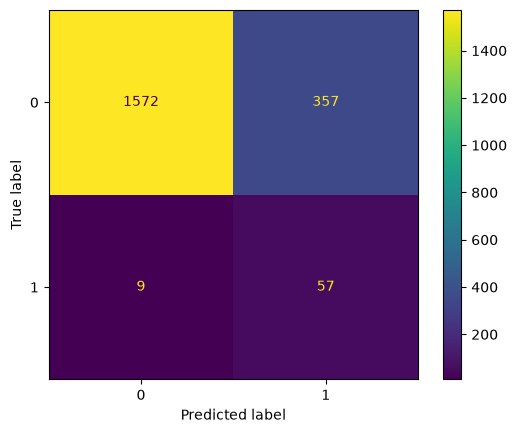

In [139]:
print('Confusion Matrix')
print('True Positive  | False Positive')
print('False Negative | True Positive')

cfm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cfm).plot()

In [140]:
print('It shows:')
print('The model got 1572 wright hits at "0" and 357 wrong hits')
print('The model got 57 wright hits at "0" and 9 wrong')

It shows:
The model got 1572 wright hits at "0" and 357 wrong hits
The model got 57 wright hits at "0" and 9 wrong


In [141]:
from sklearn.metrics import roc_auc_score, roc_curve
import plotly.graph_objects as go

y_pred_prob = logistic.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=fpr, y=tpr,
        mode="lines",
        customdata=thresholds,
))

fig.update_layout(
    title=dict(
        text = 'Roc Curve',
        x = 0.5,
        subtitle = dict(
            text = f'AUC = {auc}'
        )
    ),
    xaxis_title='False positive rate',
    yaxis_title='True positive rate',
    width=1000, height=600,
    legend=dict(x=0.6, y=0.1),
)
fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.show()


In [142]:
print('testing without balanced data')
logistic_ = LogisticRegression() # not balanced

logistic_.fit(X_train, y_train)

y_pred = logistic_.predict(X_test)

testing without balanced data


In [143]:
print('Precision: How frequent the model get it wright? Low = lots of false alarms')
print('Recall: Of all failures, how much the model got? Low = machine broke without alarm')
print('F1-score: Harmonic mean')
print('Acurracy: Right hit / all hits\n')

print(classification_report(y_test, y_pred))

Precision: How frequent the model get it wright? Low = lots of false alarms
Recall: Of all failures, how much the model got? Low = machine broke without alarm
F1-score: Harmonic mean
Acurracy: Right hit / all hits

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1929
           1       0.75      0.18      0.29        66

    accuracy                           0.97      1995
   macro avg       0.86      0.59      0.64      1995
weighted avg       0.97      0.97      0.96      1995



Confusion Matrix
True Positive  | False Positive
False Negative | True Positive


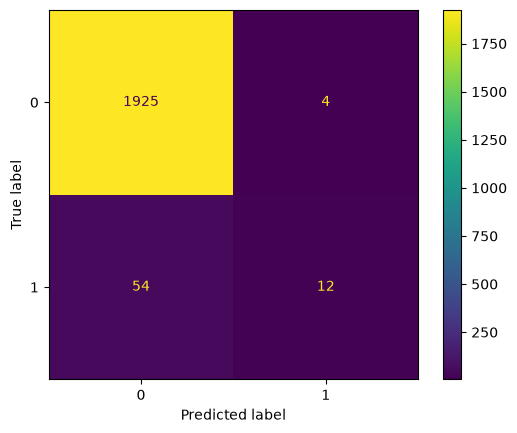

In [144]:
print('Confusion Matrix')
print('True Positive  | False Positive')
print('False Negative | True Positive')

cfm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cfm).plot()

In [145]:
from sklearn.metrics import roc_auc_score, roc_curve
import plotly.graph_objects as go

y_pred_prob = logistic_.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=fpr, y=tpr,
        mode="lines",
        customdata=thresholds,
))

fig.update_layout(
    title=dict(
        text = 'Roc Curve',
        x = 0.5,
        subtitle = dict(
            text = f'AUC = {auc}'
        )
    ),
    xaxis_title='False positive rate',
    yaxis_title='True positive rate',
    width=1000, height=600,
    legend=dict(x=0.6, y=0.1),
)
fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.show()


In [146]:
print('In this case, without class_weight="balanced", the model has higher accuracy,')
print('but only because 96.6% of the labels are zero.')
print("Where it's not critical to catch every positive case, that wouldn't be a problem.")
print('In our case, we have to decide whether we prefer more missed failures')
print('or more time wasted stopping the machine.')

In this case, without class_weight="balanced", the model has higher accuracy,
but only because 96.6% of the labels are zero.
Where it's not critical to catch every positive case, that wouldn't be a problem.
In our case, we have to decide whether we prefer more missed failures
or more time wasted stopping the machine.
